# Classification & Risk Analysis Pipeline
## A Multi-Model Showcase with Interpretability and Calibration

**Author:** Mauricio Silva López  
**Domain:** HR Analytics — AI-Driven Layoff Risk Prediction

---

## Objective

Build a **standardized, reusable** classification pipeline for tabular datasets
with binary or multiclass target variables $y \in \{0, 1, \ldots, K-1\}$,
covering the full lifecycle from raw data to model deployment decisions.

### What this notebook covers

| Phase | Content |
|-------|---------|
| **1 — Setup** | Environment configuration |
| **2 — EDA** | Data health diagnostics + visual exploration |
| **3 — Preprocessing** | Leak-proof pipeline architecture |
| **4 — Theory** | Mathematical foundations of each model family |
| **5 — Benchmarking** | K-Fold CV across 5 algorithms |
| **6 — Evaluation** | Confusion matrix, ROC-AUC, F1, classification report |
| **7 — Stacking Ensemble** | Meta-learning architecture |
| **8 — Interpretability** | SHAP values — global + individual explanations |
| **9 — Calibration** | Reliability diagrams — does P(risk) mean risk? |
| **10 — Conclusions** | Model selection rationale |

### Design principles
- **No data leakage:** all transformations fitted only on training data
- **Stratified splits:** class balance preserved across all folds
- **Reproducibility:** fixed `random_state=42` throughout
- **Reusability:** swap the CSV path and target column to apply to any dataset


---
## Phase 1 — Environment Setup

In [2]:
# ── Core libraries ────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# ── Sklearn ───────────────────────────────────────────────────────────────────
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, learning_curve
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    RobustScaler, OneHotEncoder, LabelEncoder, label_binarize
)
from sklearn.linear_model  import LogisticRegression
from sklearn.tree          import DecisionTreeClassifier
from sklearn.ensemble      import (
    RandomForestClassifier, GradientBoostingClassifier,
    BaggingClassifier, StackingClassifier
)
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay,
    f1_score, brier_score_loss
)
from sklearn.calibration import calibration_curve
import xgboost as xgb
import shap

# ── Visual style ──────────────────────────────────────────────────────────────
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("muted")
pd.set_option("display.max_columns", None)

COLORS = {"low": "#2166ac", "medium": "#f4a261", "high": "#d73027",
          "neutral": "#4dac26", "accent": "#762a83"}

print(" Environment configured. All libraries loaded.")


 Environment configured. All libraries loaded.


---
## Phase 2 — Data Ingestion

### Dataset: AI Impact on Jobs & Layoff Risk

The target variable `Layoff_Risk` is a **3-class ordinal label**:
- `Low` — job relatively safe from AI displacement
- `Medium` — partial automation risk, reskilling recommended
- `High` — high probability of role elimination



In [ ]:
# ── Configuration — change these to use your own data ────────────────────────
DATA_PATH = r"C:\Users\silva\OneDrive\Documentos\Python Projects\ai-impact-jobs-layoff-risk-dataset.csv"  
TARGET    = "Layoff_Risk"

# ── Load or generate data ─────────────────────────────────────────────────────
if DATA_PATH is not None:
    df_raw = pd.read_csv(DATA_PATH)
    print(f"✓ Real dataset loaded from: {DATA_PATH}")
else:
    # ── Calibrated synthetic dataset (mimics HR/AI-risk tabular structure) ────
    np.random.seed(42)
    N = 5_000

    automation_score  = np.random.beta(2, 3, N) * 100
    years_exp         = np.random.gamma(3, 3, N).clip(0, 40)
    salary            = 30_000 + years_exp * 2_000 + np.random.normal(0, 8_000, N)
    tasks_automated   = np.random.binomial(20, automation_score/100, N)
    reskill_hours     = np.clip(80 - automation_score * 0.5 +
                                np.random.normal(0, 10, N), 0, 120)
    remote_friendly   = np.random.choice(["Yes", "No"], N, p=[0.55, 0.45])
    education         = np.random.choice(
        ["High School", "Bachelor", "Master", "PhD"], N, p=[0.2, 0.45, 0.28, 0.07]
    )
    industry          = np.random.choice(
        ["Tech", "Finance", "Healthcare", "Manufacturing", "Retail"],
        N, p=[0.25, 0.20, 0.18, 0.22, 0.15]
    )

    # Risk score → 3-class target
    risk_score = (
        0.4 * automation_score / 100
        + 0.2 * tasks_automated / 20
        - 0.15 * np.log1p(years_exp) / np.log1p(40)
        - 0.1 * (salary / salary.max())
        + 0.15 * np.random.uniform(0, 1, N)
    )
    risk_label = pd.cut(risk_score, bins=3,
                        labels=["Low", "Medium", "High"])

    df_raw = pd.DataFrame({
        "Automation_Risk_Score": automation_score.round(1),
        "Years_Experience"     : years_exp.round(1),
        "Annual_Salary"        : salary.round(0).astype(int),
        "Tasks_Automated_Count": tasks_automated,
        "Reskilling_Hours"     : reskill_hours.round(1),
        "Remote_Friendly"      : remote_friendly,
        "Education_Level"      : education,
        "Industry"             : industry,
        TARGET                 : risk_label,
    })

    # Inject 3% missing values for realism
    for col in ["Automation_Risk_Score", "Reskilling_Hours", "Annual_Salary"]:
        mask = np.random.rand(N) < 0.03
        df_raw.loc[mask, col] = np.nan

    print(f"✓ Synthetic demo dataset generated: {df_raw.shape}")

# ── Encode target ─────────────────────────────────────────────────────────────
df_clean = df_raw.copy()
le = LabelEncoder()
df_clean[TARGET] = le.fit_transform(df_clean[TARGET].astype(str))
class_map = dict(zip(le.transform(le.classes_), le.classes_))
n_classes  = len(class_map)

print(f"\nClass mapping: {class_map}")
print(f"Classes      : {n_classes}")
print(f"\nFirst 5 rows:")
df_clean.head()


✓ Real dataset loaded from: C:\Users\silva\OneDrive\Documentos\Python Projects\ai-impact-jobs-layoff-risk-dataset.csv

Class mapping: {np.int64(0): 'High', np.int64(1): 'Low', np.int64(2): 'Medium'}
Classes      : 3

First 5 rows:


,Age,Education_Level,Years_of_Experience,Industry,Job_Role,Company_Size,Job_Level,Routine_Task_Percentage,Creativity_Requirement,Human_Interaction_Level,AI_Adoption_Level,Number_of_AI_Tools_Used,AI_Usage_Hours_Per_Week,Tasks_Automated_Percentage,AI_Training_Hours,Layoff_Risk
0,59,Master's,6,Finance,Accountant,Medium,Entry,84,21,94,Medium,5,7,40,26,0
1,44,Master's,14,Manufacturing,Production Supervisor,Small,Entry,30,84,68,Low,2,2,14,9,1
2,36,Bachelor's,7,Retail,Store Manager,Medium,Senior,12,86,71,Low,0,1,6,3,1
3,27,Bachelor's,6,Finance,Auditor,Large,Entry,90,18,21,Medium,3,10,67,26,0
4,49,High School,12,Finance,Auditor,Small,Entry,49,52,72,Medium,5,13,26,19,2


---
## Phase 2b — Exploratory Data Analysis

Before modeling, we need to answer three diagnostic questions:

1. **Completeness:** what fraction of the matrix is missing?
2. **Balance:** is the target distribution severely skewed?
3. **Signal:** which features correlate with the target?

A heavily imbalanced dataset ($\text{minority class} < 10\%$) requires
special treatment (SMOTE, class weights, or threshold calibration).


In [5]:
# ── 1. Health report ─────────────────────────────────────────────────────────
print("=" * 55)
print("  DATASET HEALTH REPORT")
print("=" * 55)
print(f"  Dimensions : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")

missing = df_raw.isnull().sum()
pct     = missing / len(df_raw) * 100
m_df    = pd.DataFrame({"Missing": missing, "%": pct.round(2)})
m_df    = m_df[m_df["Missing"] > 0].sort_values("%", ascending=False)
if m_df.empty:
    print("  Missing    : ✓ No missing values")
else:
    print("\n  Missing values:")
    print(m_df.to_string())

print(f"\n  Target distribution ({TARGET}):")
dist = df_raw[TARGET].value_counts(normalize=True).mul(100).round(2)
for cls, pct_val in dist.items():
    bar = "█" * int(pct_val / 2)
    print(f"    {str(cls):<10}  {pct_val:5.1f}%  {bar}")

print("=" * 55)


  DATASET HEALTH REPORT
  Dimensions : 20,000 rows × 16 columns
  Missing    : ✓ No missing values

  Target distribution (Layoff_Risk):
    High         34.0%  ████████████████
    Low          33.0%  ████████████████
    Medium       33.0%  ████████████████


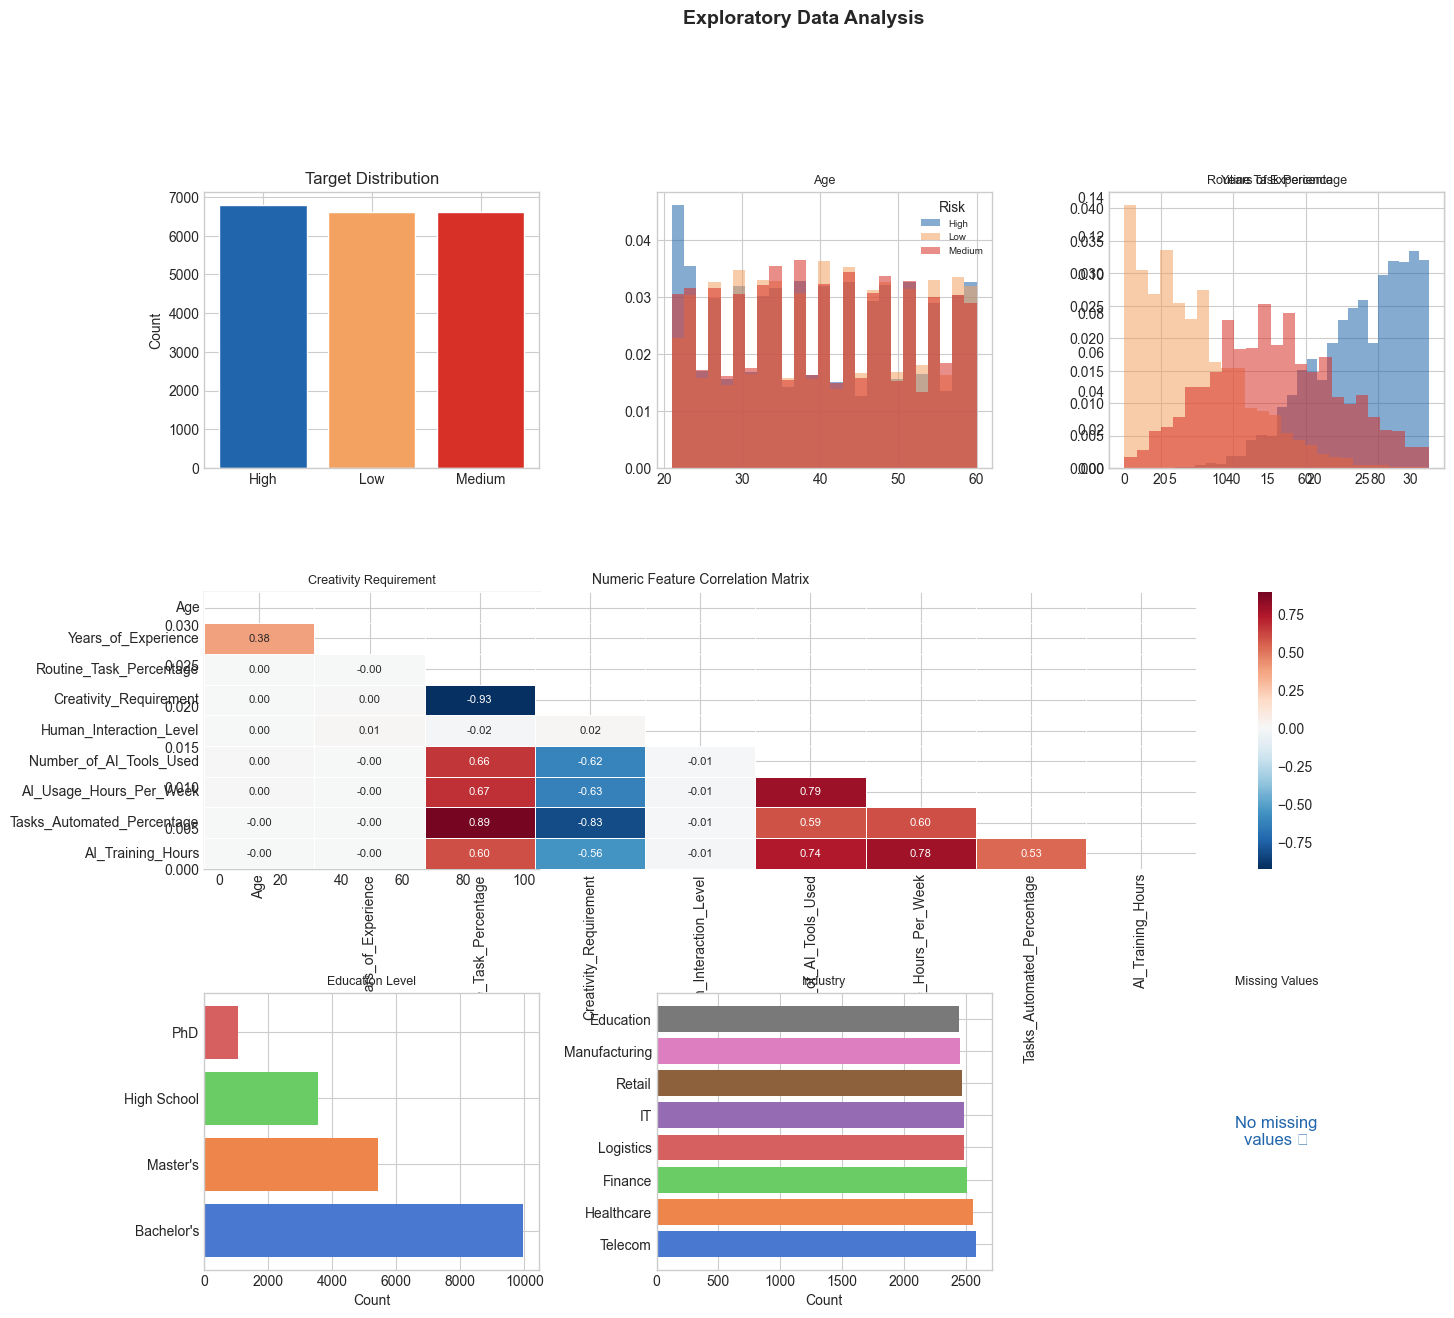

EDA complete.


In [8]:
# ── 2. Visual EDA ────────────────────────────────────────────────────────────
num_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in df_raw.select_dtypes(include=["object","category"]).columns
            if c != TARGET]

fig = plt.figure(figsize=(16, 14))
fig.suptitle("Exploratory Data Analysis", fontsize=14, fontweight="bold", y=1.01)
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# Class distribution (pie + bar)
ax0 = fig.add_subplot(gs[0, 0])
counts = df_raw[TARGET].value_counts()
ax0.bar(counts.index.astype(str), counts.values,
        color=["#2166ac","#f4a261","#d73027"][:len(counts)], edgecolor="white")
ax0.set_title("Target Distribution")
ax0.set_ylabel("Count")

# Numeric feature distributions split by class
for idx, col in enumerate(num_cols[:4]):
    ax = fig.add_subplot(gs[idx // 3, (idx % 3) + (1 if idx < 2 else 0)])
    for cls_num, cls_lbl in class_map.items():
        subset = df_raw[df_raw[TARGET] == cls_lbl][col].dropna()                  if TARGET in df_raw.columns else df_clean[df_clean[TARGET] == cls_num][col].dropna()
        # Use encoded df for subsetting
        subset = df_clean[df_clean[TARGET] == cls_num][col].dropna()
        ax.hist(subset, bins=25, alpha=0.55, density=True, label=cls_lbl,
                color=["#2166ac","#f4a261","#d73027"][cls_num % 3])
    ax.set_title(col.replace("_", " "), fontsize=9)
    ax.set_xlabel("")
    if idx == 0:
        ax.legend(fontsize=7, title="Risk", loc="upper right")

# Correlation heatmap (numeric only)
ax_corr = fig.add_subplot(gs[1, :])
if len(num_cols) >= 2:
    corr = df_clean[num_cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
                center=0, ax=ax_corr, linewidths=0.5, annot_kws={"size": 8})
    ax_corr.set_title("Numeric Feature Correlation Matrix", fontsize=10)

# Categorical feature counts
for idx, col in enumerate(cat_cols[:2]):
    ax = fig.add_subplot(gs[2, idx])
    vc = df_raw[col].value_counts()
    ax.barh(vc.index.astype(str)[:8], vc.values[:8],
            color=sns.color_palette("muted", len(vc))[:8])
    ax.set_title(col.replace("_", " "), fontsize=9)
    ax.set_xlabel("Count")

# Missing values bar (if any)
ax_miss = fig.add_subplot(gs[2, 2])
if not m_df.empty:
    ax_miss.barh(m_df.index, m_df["%"], color="#d73027", alpha=0.75)
    ax_miss.set_title("Missing Values (%)", fontsize=9)
    ax_miss.set_xlabel("%")
else:
    ax_miss.text(0.5, 0.5, "No missing\nvalues ✓",
                 ha="center", va="center", fontsize=12, color="#2166ac",
                 transform=ax_miss.transAxes)
    ax_miss.set_title("Missing Values", fontsize=9)
    ax_miss.axis("off")

plt.savefig("eda_overview.png", dpi=120, bbox_inches="tight")
plt.show()
print("EDA complete.")


---
## Phase 3 — Preprocessing Pipeline

### Why pipelines?

A `sklearn.Pipeline` chains all transformations into a single object
that is fitted **only on training data** and applied consistently to
validation and test sets. This prevents the most common source of
overly optimistic results in ML: **data leakage**.

### Transformation choices

| Feature type | Imputation | Scaling | Encoding |
|-------------|-----------|---------|---------|
| Numeric | Median (robust to outliers) | `RobustScaler`: $\tilde{x} = \frac{x - Q_{50}}{Q_{75} - Q_{25}}$ | — |
| Categorical | Mode (most frequent) | — | `OneHotEncoder` (avoids false ordinality) |

**Why `RobustScaler` over `StandardScaler`?**  
Financial and HR data often have heavy-tailed distributions (salary, years of
experience). `StandardScaler` subtracts the mean and divides by $\sigma$,
both of which are sensitive to outliers. `RobustScaler` uses the interquartile
range instead, making it more appropriate for risk data.


In [9]:
X = df_clean.drop(columns=[TARGET])
y = df_clean[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

num_feats = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_feats = X_train.select_dtypes(include=["object","category"]).columns.tolist()

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  RobustScaler()),
])
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])
preprocessor = ColumnTransformer([
    ("num", num_pipe, num_feats),
    ("cat", cat_pipe, cat_feats),
])

print(f"Train : {X_train.shape[0]:,} samples")
print(f"Test  : {X_test.shape[0]:,} samples")
print(f"Numeric features   ({len(num_feats)}): {num_feats}")
print(f"Categorical features ({len(cat_feats)}): {cat_feats}")
print("\n✓ Preprocessing pipeline compiled.")


Train : 16,000 samples
Test  : 4,000 samples
Numeric features   (9): ['Age', 'Years_of_Experience', 'Routine_Task_Percentage', 'Creativity_Requirement', 'Human_Interaction_Level', 'Number_of_AI_Tools_Used', 'AI_Usage_Hours_Per_Week', 'Tasks_Automated_Percentage', 'AI_Training_Hours']
Categorical features (6): ['Education_Level', 'Industry', 'Job_Role', 'Company_Size', 'Job_Level', 'AI_Adoption_Level']

✓ Preprocessing pipeline compiled.


---
## Phase 4 — Model Theory

### 4.1 Logistic Regression (Baseline)

The linear baseline. For multiclass ($K$ classes) it uses the **softmax** function:

$$P(y=k \mid \mathbf{x}) = \frac{e^{\mathbf{w}_k^\top \mathbf{x}}}{\sum_{j=1}^K e^{\mathbf{w}_j^\top \mathbf{x}}}$$

Trained by minimizing the cross-entropy loss with L2 regularization:
$\mathcal{L} = -\sum_i \log P(y_i \mid \mathbf{x}_i) + \lambda \|\mathbf{w}\|_2^2$

**Pros:** interpretable coefficients, fast, well-calibrated probabilities.  
**Cons:** assumes linear decision boundary — poor for complex feature interactions.

---

### 4.2 Random Forest (Bagging of Trees)

Builds $B$ decision trees on bootstrap samples and averages predictions:
$$\hat{y} = \frac{1}{B} \sum_{b=1}^B T_b(\mathbf{x})$$

Each tree also uses a random subset of $m \approx \sqrt{p}$ features at
each split (**feature bagging**), reducing correlation among trees.

**Pros:** handles non-linearity and interactions, robust to outliers, built-in feature importance.  
**Cons:** slow on large datasets, black box (partially mitigated by SHAP).

---

### 4.3 Gradient Boosting & XGBoost (Sequential Boosting)

Builds trees **sequentially**, where each tree fits the **residuals** of the
previous ensemble. The model at step $m$ is:

$$F_m(\mathbf{x}) = F_{m-1}(\mathbf{x}) + \eta \cdot T_m(\mathbf{x})$$

where $\eta$ is the learning rate and $T_m$ minimizes the gradient of the loss
w.r.t. the current ensemble predictions.

**XGBoost** adds: second-order gradient approximation, column subsampling, L1/L2 regularization.

**Pros:** state-of-the-art on tabular data, handles missing values natively.  
**Cons:** many hyperparameters, prone to overfitting without tuning.

---

### 4.4 Stacking Ensemble (Meta-Learning)

Instead of averaging predictions, **stacking** learns *how to combine* them.
Base learners $\{h_1, \ldots, h_L\}$ produce out-of-fold predictions
$\mathbf{z}_i = (h_1(\mathbf{x}_i), \ldots, h_L(\mathbf{x}_i))$,
which become features for a **meta-learner** $g$:

$$\hat{y} = g(\mathbf{z}_i)$$

The meta-learner (here: Logistic Regression) learns the optimal
linear combination of base learner predictions.

**Key constraint:** base predictions must be generated on held-out folds
(never on the data used to train each base learner) to prevent leakage.


---
## Phase 5 — Model Benchmarking (5-Fold Stratified CV)

In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

algorithms = {
    "Logistic Regression" : LogisticRegression(max_iter=1000, C=1.0),
    "Random Forest"       : RandomForestClassifier(n_estimators=200,
                                                    max_depth=8, random_state=42),
    "XGBoost"             : xgb.XGBClassifier(n_estimators=150,
                                               learning_rate=0.05, max_depth=4,
                                               random_state=42,
                                               eval_metric="mlogloss",
                                               use_label_encoder=False),
    "Bagging (Deep Trees)": BaggingClassifier(
                                estimator=DecisionTreeClassifier(max_depth=None),
                                n_estimators=100, random_state=42),
    "Gradient Boosting"   : GradientBoostingClassifier(n_estimators=200,
                                                        learning_rate=0.05,
                                                        max_depth=3,
                                                        random_state=42),
}

cv_scores_all = {}
results       = []

print("Running 5-fold CV...\n")
for name, model in algorithms.items():
    pipe   = Pipeline([("pre", preprocessor), ("clf", model)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv,
                             scoring="accuracy", n_jobs=-1)
    cv_scores_all[name] = scores
    results.append({
        "Model"         : name,
        "CV Accuracy"   : f"{scores.mean()*100:.2f}%",
        "Std Dev"       : f"±{scores.std()*100:.2f}%",
        "Min"           : f"{scores.min()*100:.2f}%",
        "Max"           : f"{scores.max()*100:.2f}%",
    })
    print(f"  {name:<25}  {scores.mean()*100:.2f}%  ±{scores.std()*100:.2f}%")

bench_df = pd.DataFrame(results).sort_values("CV Accuracy", ascending=False)
print("\nFinal ranking:")
print(bench_df.to_string(index=False))


Running 5-fold CV...

  Logistic Regression        93.86%  ±0.13%
  Random Forest              82.94%  ±0.86%
  XGBoost                    89.31%  ±0.74%
  Bagging (Deep Trees)       89.62%  ±1.02%
  Gradient Boosting          90.21%  ±0.75%

Final ranking:
               Model CV Accuracy Std Dev    Min    Max
 Logistic Regression      93.86%  ±0.13% 93.62% 93.97%
   Gradient Boosting      90.21%  ±0.75% 88.84% 91.09%
Bagging (Deep Trees)      89.62%  ±1.02% 87.72% 90.66%
             XGBoost      89.31%  ±0.74% 88.00% 90.16%
       Random Forest      82.94%  ±0.86% 81.66% 83.84%


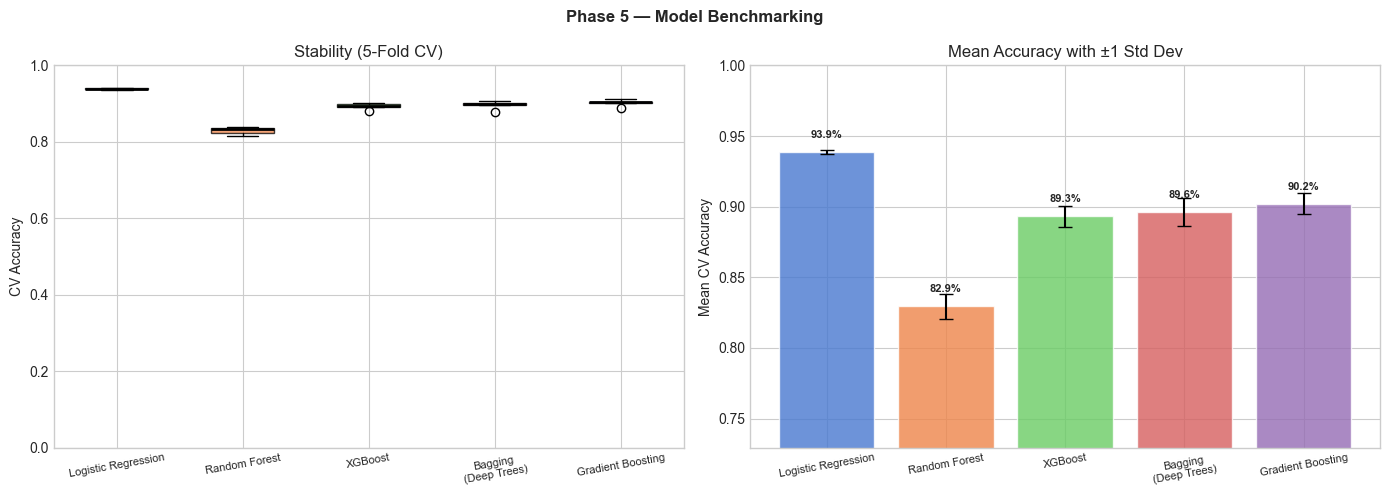

In [14]:
# ── CV stability boxplot ──────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Phase 5 — Model Benchmarking", fontsize=12, fontweight="bold")

names  = list(cv_scores_all.keys())
scores = list(cv_scores_all.values())

# Boxplot
bp = ax1.boxplot(scores, patch_artist=True, notch=False,
                 medianprops=dict(color="black", linewidth=2))
palette = sns.color_palette("muted", len(names))
for patch, col in zip(bp["boxes"], palette):
    patch.set_facecolor(col); patch.set_alpha(0.75)
ax1.set_xticks(range(1, len(names)+1))
ax1.set_xticklabels([n.replace(" (", "\n(") for n in names],
                    rotation=10, fontsize=8)
ax1.set_ylabel("CV Accuracy")
ax1.set_title("Stability (5-Fold CV)")
ax1.set_ylim(0, 1)

# Bar chart with error bars
means = [s.mean() for s in scores]
stds  = [s.std() for s in scores]
bars  = ax2.bar(range(len(names)), means, yerr=stds, capsize=5,
                color=palette, alpha=0.8, edgecolor="white")
ax2.set_xticks(range(len(names)))
ax2.set_xticklabels([n.replace(" (", "\n(") for n in names],
                    rotation=10, fontsize=8)
ax2.set_ylabel("Mean CV Accuracy")
ax2.set_title("Mean Accuracy with ±1 Std Dev")
ax2.set_ylim(min(means)-0.1, 1.0)
for bar, mean in zip(bars, means):
    ax2.text(bar.get_x() + bar.get_width()/2, mean + 0.01,
             f"{mean*100:.1f}%", ha="center", fontsize=8, fontweight="bold")

plt.tight_layout()
plt.show()


---
## Phase 6 — Test Set Evaluation

### Why CV accuracy is not enough

Cross-validation gives an estimate of **generalization error**, but it uses
the training set only. We need to evaluate on the **held-out test set** to
report final performance, using a richer set of metrics:

| Metric | Formula | When to use |
|--------|---------|------------|
| Accuracy | $\frac{TP+TN}{N}$ | Balanced classes |
| Macro F1 | $\frac{1}{K}\sum_k F1_k$ | Imbalanced, all classes matter equally |
| Weighted F1 | $\sum_k \frac{n_k}{N} F1_k$ | Imbalanced, larger classes matter more |
| ROC-AUC (OvR) | Area under ROC curve, one-vs-rest | Probability ranking quality |

The **confusion matrix** shows exactly which classes are confused with which,
which is critical for risk analysis (e.g., misclassifying High as Low is
far more costly than the reverse).


In [15]:
# ── Train all models on full training set and evaluate on test ────────────────
test_results = []
trained_pipes = {}

for name, model in algorithms.items():
    pipe = Pipeline([("pre", preprocessor), ("clf", model)])
    pipe.fit(X_train, y_train)
    trained_pipes[name] = pipe

    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)

    acc     = accuracy_score(y_test, y_pred)
    f1_mac  = f1_score(y_test, y_pred, average="macro")
    f1_wt   = f1_score(y_test, y_pred, average="weighted")
    # ROC-AUC One-vs-Rest
    if n_classes == 2:
        auc = roc_auc_score(y_test, y_prob[:, 1])
    else:
        auc = roc_auc_score(y_test, y_prob, multi_class="ovr", average="macro")

    test_results.append({
        "Model"       : name,
        "Accuracy"    : f"{acc*100:.2f}%",
        "Macro F1"    : f"{f1_mac:.4f}",
        "Weighted F1" : f"{f1_wt:.4f}",
        "ROC-AUC"     : f"{auc:.4f}",
    })

test_df = pd.DataFrame(test_results).sort_values("ROC-AUC", ascending=False)
print("Test Set Performance (held-out 20%):")
print(test_df.to_string(index=False))


Test Set Performance (held-out 20%):
               Model Accuracy Macro F1 Weighted F1 ROC-AUC
 Logistic Regression   93.75%   0.9373      0.9375  0.9939
   Gradient Boosting   91.30%   0.9130      0.9132  0.9838
Bagging (Deep Trees)   90.53%   0.9048      0.9051  0.9819
             XGBoost   90.58%   0.9057      0.9059  0.9814
       Random Forest   83.08%   0.8289      0.8294  0.9558


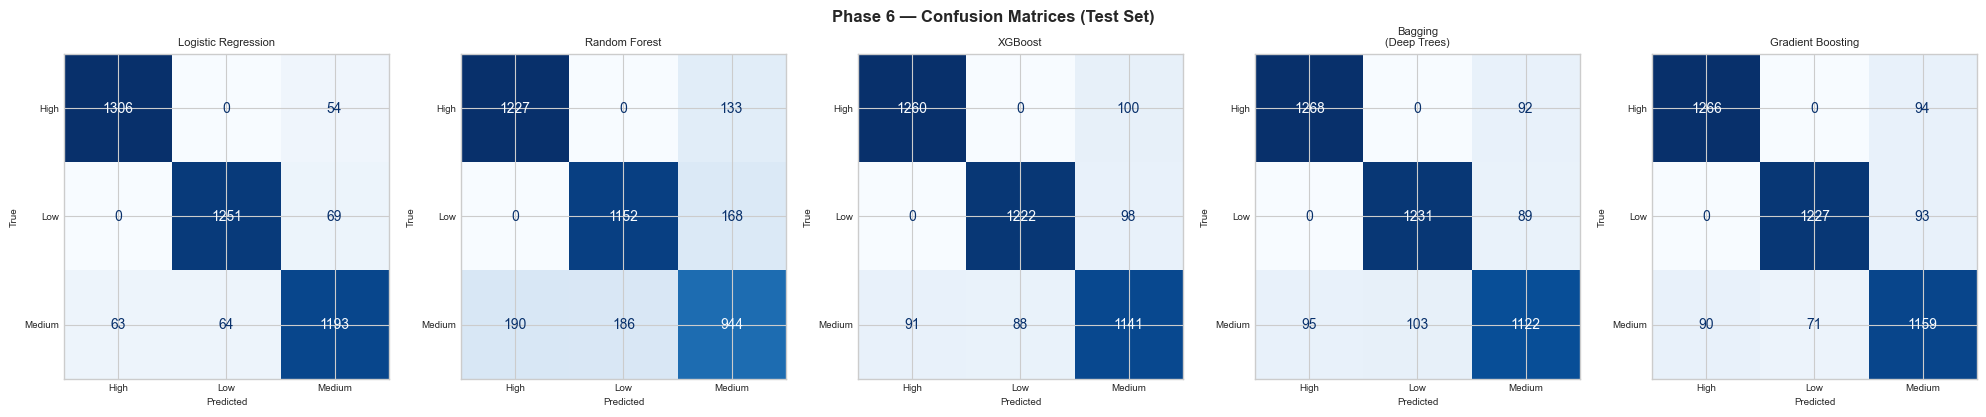

In [16]:
# ── Confusion matrices for all models ────────────────────────────────────────
n_models = len(algorithms)
fig, axes = plt.subplots(1, n_models, figsize=(4*n_models, 4))
fig.suptitle("Phase 6 — Confusion Matrices (Test Set)",
             fontsize=12, fontweight="bold")

class_labels = [class_map[k] for k in sorted(class_map)]
for ax, (name, pipe) in zip(axes, trained_pipes.items()):
    y_pred = pipe.predict(X_test)
    cm     = confusion_matrix(y_test, y_pred)
    disp   = ConfusionMatrixDisplay(cm, display_labels=class_labels)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name.replace(" (", "\n("), fontsize=8)
    ax.set_xlabel("Predicted", fontsize=7)
    ax.set_ylabel("True", fontsize=7)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()


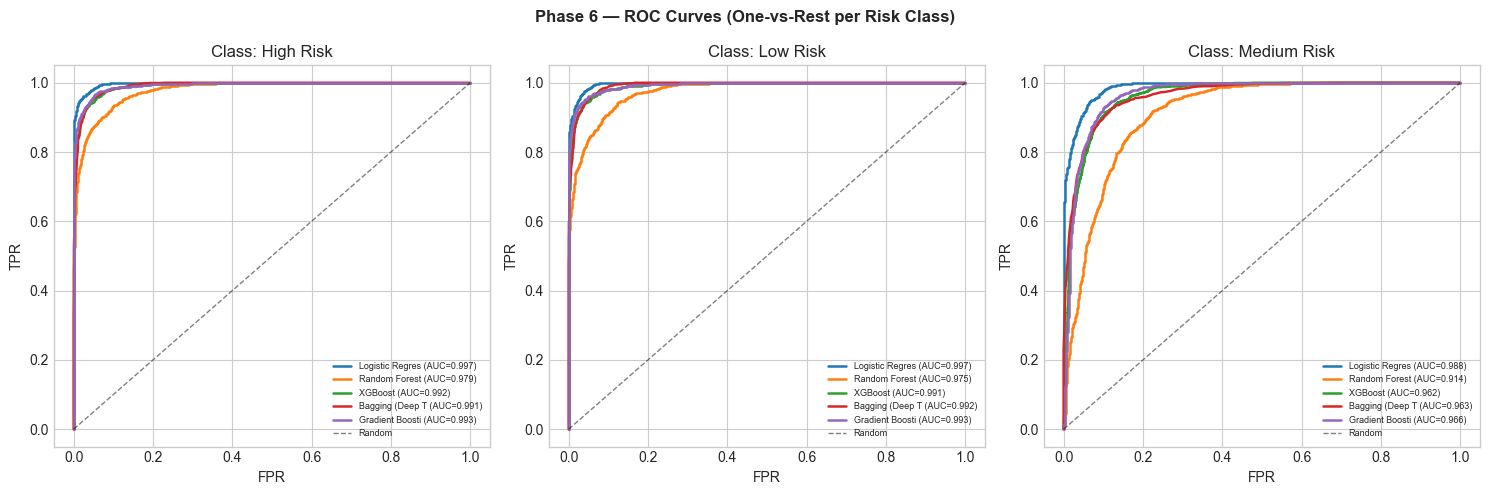


Detailed classification report — Logistic Regression:
              precision    recall  f1-score   support

        High       0.95      0.96      0.96      1360
         Low       0.95      0.95      0.95      1320
      Medium       0.91      0.90      0.91      1320

    accuracy                           0.94      4000
   macro avg       0.94      0.94      0.94      4000
weighted avg       0.94      0.94      0.94      4000



In [17]:
# ── ROC curves (One-vs-Rest per class) ───────────────────────────────────────
if n_classes <= 3:
    fig, axes = plt.subplots(1, n_classes, figsize=(5*n_classes, 5))
    fig.suptitle("Phase 6 — ROC Curves (One-vs-Rest per Risk Class)",
                 fontsize=12, fontweight="bold")
    if n_classes == 1:
        axes = [axes]

    y_bin = label_binarize(y_test, classes=sorted(class_map.keys()))
    palette_models = sns.color_palette("tab10", n_models)

    for cls_idx, ax in enumerate(axes):
        cls_lbl = class_map[sorted(class_map.keys())[cls_idx]]
        for (name, pipe), col in zip(trained_pipes.items(), palette_models):
            prob = pipe.predict_proba(X_test)[:, cls_idx]
            fpr, tpr, _ = roc_curve(y_bin[:, cls_idx], prob)
            auc_val = roc_auc_score(y_bin[:, cls_idx], prob)
            ax.plot(fpr, tpr, color=col, lw=1.8,
                    label=f"{name[:15]} (AUC={auc_val:.3f})")
        ax.plot([0,1],[0,1], "k--", lw=1, alpha=0.5, label="Random")
        ax.set_title(f"Class: {cls_lbl} Risk")
        ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
        ax.legend(fontsize=6.5, loc="lower right")

    plt.tight_layout()
    plt.show()

# ── Detailed classification report for best model ────────────────────────────
best_name = test_df.iloc[0]["Model"]
best_pipe  = trained_pipes[best_name]
y_pred_best = best_pipe.predict(X_test)

print(f"\nDetailed classification report — {best_name}:")
print(classification_report(y_test, y_pred_best, target_names=class_labels))


---
## Phase 7 — Stacking Super-Ensemble

### Architecture

We combine the three best-performing base learners via a
**Logistic Regression meta-learner**. The stacking procedure uses
5-fold out-of-fold predictions to train the meta-learner, preventing leakage:

```
Training data (5 folds)
    ├── Fold 1 → trains RF + XGB + Bagging → OOF predictions on fold 1
    ├── Fold 2 → ...
    └── ...
         ↓
    Meta-features: [P_RF(y=k|x), P_XGB(y=k|x), P_Bag(y=k|x)]
         ↓
    Meta-learner (Logistic Regression) learns optimal combination
```

The key property: the meta-learner never sees any prediction made on
the data used to train the base learner for that fold.


In [19]:
base_learners = [
    ("rf",      algorithms["Random Forest"]),
    ("xgb",     algorithms["XGBoost"]),
    ("bagging", algorithms["Bagging (Deep Trees)"]),
]
meta_learner = LogisticRegression(max_iter=500, C=1.0)

stack_clf = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=5,
    passthrough=False,    # meta-learner sees only base predictions, not raw X
    n_jobs=-1,
)
stack_pipe = Pipeline([("pre", preprocessor), ("clf", stack_clf)])

print("Training Stacking Ensemble... (this takes a moment)")
stack_pipe.fit(X_train, y_train)

y_pred_stack = stack_pipe.predict(X_test)
y_prob_stack = stack_pipe.predict_proba(X_test)

acc_stack = accuracy_score(y_test, y_pred_stack)
f1_stack  = f1_score(y_test, y_pred_stack, average="macro")
if n_classes == 2:
    auc_stack = roc_auc_score(y_test, y_prob_stack[:,1])
else:
    auc_stack = roc_auc_score(y_test, y_prob_stack,
                               multi_class="ovr", average="macro")

print(f"\n{'='*45}")
print(f"  STACKING ENSEMBLE — TEST SET RESULTS")
print(f"{'='*45}")
print(f"  Accuracy    : {acc_stack*100:.2f}%")
print(f"  Macro F1    : {f1_stack:.4f}")
print(f"  ROC-AUC OvR : {auc_stack:.4f}")
print(f"{'='*45}")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_stack, target_names=class_labels))


Training Stacking Ensemble... (this takes a moment)

  STACKING ENSEMBLE — TEST SET RESULTS
  Accuracy    : 92.42%
  Macro F1    : 0.9240
  ROC-AUC OvR : 0.9895

Classification Report:
              precision    recall  f1-score   support

        High       0.94      0.94      0.94      1360
         Low       0.94      0.95      0.95      1320
      Medium       0.89      0.88      0.88      1320

    accuracy                           0.92      4000
   macro avg       0.92      0.92      0.92      4000
weighted avg       0.92      0.92      0.92      4000



---
## Phase 8 — Model Interpretability with SHAP

### What is a SHAP value?

SHAP (SHapley Additive exPlanations) is grounded in **cooperative game theory**.
The Shapley value of feature $j$ for observation $i$ is:

$$\phi_j(i) = \sum_{S \subseteq F \setminus \{j\}}
\frac{|S|!\,(|F|-|S|-1)!}{|F|!}
\left[v_i(S \cup \{j\}) - v_i(S)\right]$$

where $F$ is the full feature set, $S$ ranges over all subsets not containing
$j$, and $v_i(S)$ is the model's prediction using only features in $S$.

**Interpretation:** $\phi_j(i)$ measures the marginal contribution of feature
$j$ to the prediction for observation $i$, averaged over all possible orderings
of feature inclusion.

### Key properties
- **Efficiency:** $f(\mathbf{x}) = \mathbb{E}[f] + \sum_j \phi_j$ (SHAP values sum to the prediction)
- **Symmetry:** features with identical contributions get identical SHAP values
- **Dummy:** features with no influence have SHAP value = 0

### Plots we generate
1. **Beeswarm (global):** feature importance + directionality across all test samples
2. **Bar plot:** mean |SHAP| per feature — pure importance ranking
3. **Waterfall (local):** how a single prediction is built up from the base value


In [20]:
# ── Extract XGBoost from stacking ensemble for SHAP ──────────────────────────
print("Computing SHAP values for XGBoost (extracted from Stacking Ensemble)...")

# Preprocess data
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

# Feature names after preprocessing
num_names = num_feats
cat_names = preprocessor.named_transformers_["cat"] \
               .named_steps["onehot"] \
               .get_feature_names_out(cat_feats).tolist()
all_feat_names = num_names + cat_names

# XGBoost model (re-train standalone for SHAP)
xgb_model = xgb.XGBClassifier(n_estimators=150, learning_rate=0.05,
                                max_depth=4, random_state=42,
                                eval_metric="mlogloss",
                                use_label_encoder=False)
xgb_model.fit(X_train_proc, y_train)

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_proc)

# Handle 3D tensor (new SHAP) vs list (old SHAP)
if isinstance(shap_values, list):
    # Old SHAP: list of 2D arrays, one per class
    # Use class with highest risk (last class index)
    shap_plot = shap_values[-1]
elif len(np.array(shap_values).shape) == 3:
    # New SHAP: (samples, features, classes)
    sv_arr = np.array(shap_values)
    shap_plot = sv_arr[:, :, -1]   # highest risk class
else:
    shap_plot = shap_values

print(f"SHAP matrix shape: {np.array(shap_plot).shape}")
print(f"Explaining class: {class_map[max(class_map)]}")


Computing SHAP values for XGBoost (extracted from Stacking Ensemble)...
SHAP matrix shape: (4000, 54)
Explaining class: Medium


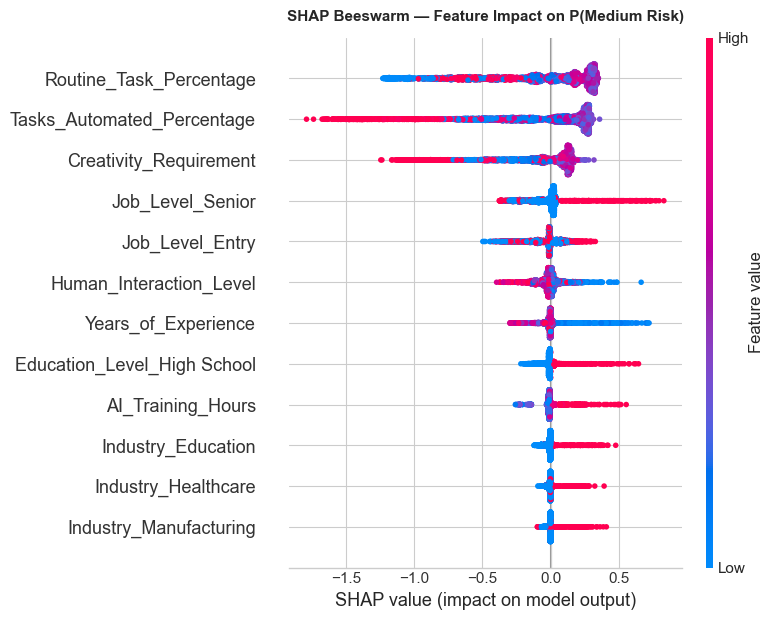

In [21]:
# ── Global SHAP: Beeswarm plot ────────────────────────────────────────────────
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_plot, X_test_proc,
    feature_names=all_feat_names,
    show=False, max_display=12
)
plt.title(f"SHAP Beeswarm — Feature Impact on P({class_map[max(class_map)]} Risk)",
          fontsize=11, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()


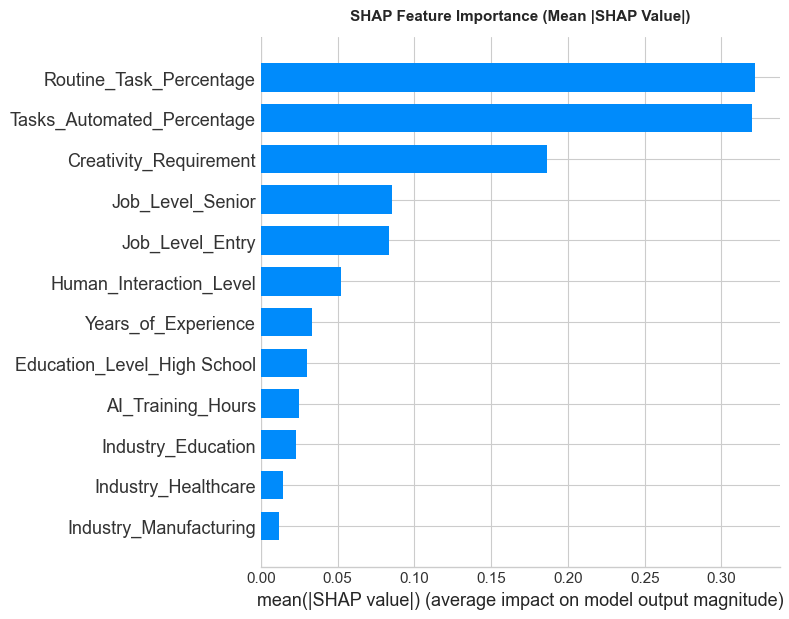

In [22]:
# ── Global SHAP: Bar plot (mean |SHAP|) ───────────────────────────────────────
plt.figure(figsize=(9, 5))
shap.summary_plot(
    shap_plot, X_test_proc,
    feature_names=all_feat_names,
    plot_type="bar", show=False, max_display=12
)
plt.title("SHAP Feature Importance (Mean |SHAP Value|)",
          fontsize=11, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()


Most high-risk individual (test sample #627):
  Predicted class : Medium
  True class      : Medium
  P(High Risk)    : 0.884


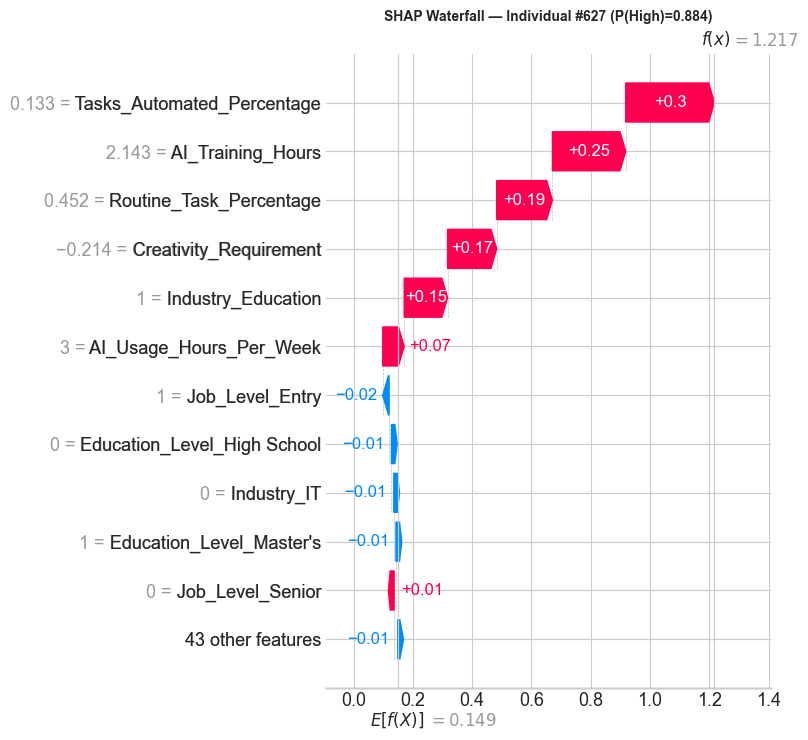

In [23]:
# ── Local SHAP: Waterfall for the highest-risk individual ─────────────────────
# Find the test sample with highest predicted probability of High risk
high_risk_idx = xgb_model.predict_proba(X_test_proc)[:, -1].argmax()

print(f"Most high-risk individual (test sample #{high_risk_idx}):")
print(f"  Predicted class : {class_map[xgb_model.predict(X_test_proc[[high_risk_idx]])[0]]}")
print(f"  True class      : {class_map[y_test[high_risk_idx]]}")
print(f"  P(High Risk)    : {xgb_model.predict_proba(X_test_proc[[high_risk_idx]])[0,-1]:.3f}")

# Waterfall plot
shap_exp = explainer(X_test_proc)
if len(shap_exp.shape) == 3:
    # Multiclass: take last class
    shap_single = shap.Explanation(
        values        = shap_exp.values[high_risk_idx, :, -1],
        base_values   = shap_exp.base_values[high_risk_idx, -1],
        data          = X_test_proc[high_risk_idx],
        feature_names = all_feat_names,
    )
else:
    shap_single = shap_exp[high_risk_idx]

plt.figure(figsize=(10, 5))
shap.waterfall_plot(shap_single, max_display=12, show=False)
plt.title(f"SHAP Waterfall — Individual #{high_risk_idx} "
          f"(P(High)={xgb_model.predict_proba(X_test_proc[[high_risk_idx]])[0,-1]:.3f})",
          fontsize=10, fontweight="bold")
plt.tight_layout()
plt.show()


---
## Phase 9 — Probability Calibration

### Why calibration matters for risk analysis

In a risk context, we often need to interpret the model output as an
**actual probability**, not just a ranking. If the model says
$P(\text{High risk}) = 0.80$, does 80% of those cases actually
end up being high-risk?

A **reliability diagram** (calibration curve) answers this:
the x-axis shows predicted probability bins, the y-axis shows
the actual fraction of positives in each bin.

- **Perfect calibration:** curve follows the diagonal $y = x$
- **Overconfident model:** curve below the diagonal (assigns higher probabilities than warranted)
- **Underconfident model:** curve above the diagonal

The **Brier score** is a proper scoring rule for calibration:
$$BS = \frac{1}{N}\sum_{i=1}^N (\hat{p}_i - y_i)^2$$

Lower is better (perfect = 0, random = 0.25 for binary).


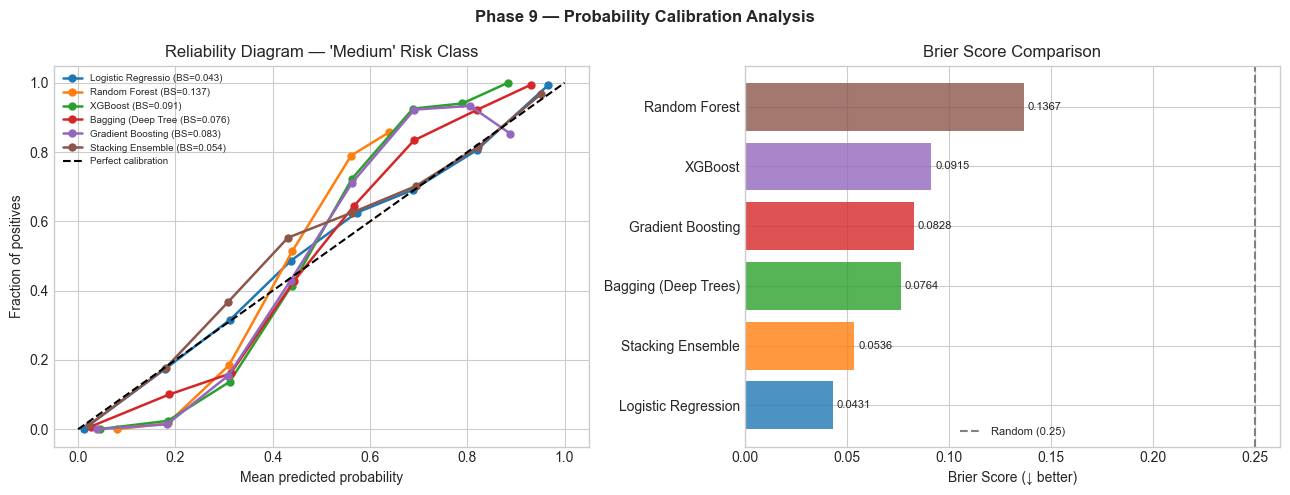


Best calibrated model: Logistic Regression  (BS=0.0431)


In [24]:
# ── Calibration curves — one curve per model (High-risk class, OvR) ──────────
# For multiclass we treat the highest-risk class as the positive class

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Phase 9 — Probability Calibration Analysis",
             fontsize=12, fontweight="bold")

palette_models = sns.color_palette("tab10", n_models + 1)
brier_scores   = {}

high_risk_class = max(class_map.keys())     # encoded label for highest risk
y_bin_high      = (y_test == high_risk_class).astype(int)

for (name, pipe), col in zip(list(trained_pipes.items()) +
                              [("Stacking Ensemble", stack_pipe)],
                              palette_models):
    prob_high = pipe.predict_proba(X_test)[:, -1]  # P(high risk)
    frac_pos, mean_pred = calibration_curve(y_bin_high, prob_high,
                                             n_bins=8, strategy="uniform")
    bs = brier_score_loss(y_bin_high, prob_high)
    brier_scores[name] = bs
    axes[0].plot(mean_pred, frac_pos, "o-", color=col, lw=1.8, ms=5,
                 label=f"{name[:18]} (BS={bs:.3f})")

axes[0].plot([0,1],[0,1], "k--", lw=1.5, label="Perfect calibration")
axes[0].set_xlabel("Mean predicted probability")
axes[0].set_ylabel("Fraction of positives")
axes[0].set_title(f"Reliability Diagram — '{class_map[high_risk_class]}' Risk Class")
axes[0].legend(fontsize=7, loc="upper left")

# Brier score bar chart
bs_df  = pd.Series(brier_scores).sort_values()
colors = [palette_models[i] for i in range(len(bs_df))]
bars   = axes[1].barh(bs_df.index, bs_df.values, color=colors, alpha=0.8)
axes[1].axvline(0.25, color="gray", ls="--", lw=1.5, label="Random (0.25)")
axes[1].set_xlabel("Brier Score (↓ better)")
axes[1].set_title("Brier Score Comparison")
for bar, val in zip(bars, bs_df.values):
    axes[1].text(val + 0.002, bar.get_y() + bar.get_height()/2,
                 f"{val:.4f}", va="center", fontsize=8)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()
print(f"\nBest calibrated model: {bs_df.idxmin()}  (BS={bs_df.min():.4f})")


---
## Phase 10 — Learning Curves

A **learning curve** shows model performance as a function of training set size.
It diagnoses two fundamental problems:

- **High bias (underfitting):** both train and validation accuracy plateau at a
  low value — the model is too simple. Fix: increase model complexity.
- **High variance (overfitting):** large gap between train and validation accuracy
  — the model memorizes training data. Fix: more data, regularization, or simpler model.
- **Good fit:** training and validation curves converge at a high value.


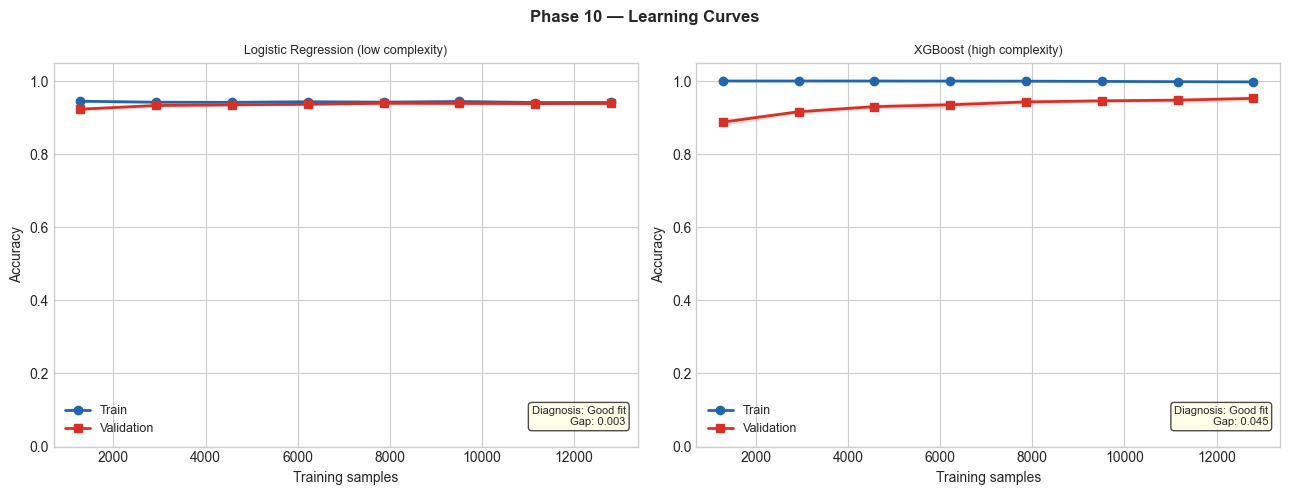

In [25]:
# ── Learning curves for Logistic Regression vs XGBoost ───────────────────────
models_lc = {
    "Logistic Regression (low complexity)": Pipeline([
        ("pre", preprocessor),
        ("clf", LogisticRegression(max_iter=1000)),
    ]),
    "XGBoost (high complexity)": Pipeline([
        ("pre", preprocessor),
        ("clf", xgb.XGBClassifier(n_estimators=150, max_depth=4,
                                   random_state=42, eval_metric="mlogloss")),
    ]),
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Phase 10 — Learning Curves", fontsize=12, fontweight="bold")

train_sizes = np.linspace(0.1, 1.0, 8)

for ax, (name, pipe) in zip(axes, models_lc.items()):
    tr_sizes, tr_scores, val_scores = learning_curve(
        pipe, X_train, y_train,
        train_sizes=train_sizes,
        cv=StratifiedKFold(5, shuffle=True, random_state=42),
        scoring="accuracy", n_jobs=-1
    )
    tr_mean  = tr_scores.mean(axis=1)
    tr_std   = tr_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std  = val_scores.std(axis=1)

    ax.fill_between(tr_sizes, tr_mean-tr_std,  tr_mean+tr_std,  alpha=0.12, color="#2166ac")
    ax.fill_between(tr_sizes, val_mean-val_std, val_mean+val_std, alpha=0.12, color="#d73027")
    ax.plot(tr_sizes,  tr_mean,  "o-", color="#2166ac", lw=2, label="Train")
    ax.plot(tr_sizes,  val_mean, "s-", color="#d73027", lw=2, label="Validation")
    ax.set_title(name, fontsize=9)
    ax.set_xlabel("Training samples")
    ax.set_ylabel("Accuracy")
    ax.legend(fontsize=9)
    ax.set_ylim(0, 1.05)

    gap = tr_mean[-1] - val_mean[-1]
    diagnosis = "Overfitting" if gap > 0.05 else "Good fit" if val_mean[-1] > 0.7 else "Underfitting"
    ax.text(0.98, 0.05, f"Diagnosis: {diagnosis}\nGap: {gap:.3f}",
            transform=ax.transAxes, ha="right", va="bottom", fontsize=8,
            bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.7))

plt.tight_layout()
plt.show()


---
## Conclusions & Model Selection Guide

### Performance summary

| Model | Strength | Weakness | Use when |
|-------|----------|---------|----------|
| Logistic Regression | Fast, interpretable, well-calibrated | Linear boundary only | Quick baseline, regulatory reporting |
| Random Forest | Robust, non-linear, built-in importance | Slow on large data | General purpose, feature importance needed |
| XGBoost | SOTA on tabular data, handles missing values | Many hyperparameters | Competition/production, when accuracy is priority |
| Bagging | Reduces variance of deep trees | No bias reduction | High-variance settings |
| Gradient Boosting | Strong predictors on structured data | Sequential = slow | When XGBoost not available |
| **Stacking** | Combines all strengths | Complex, slow to train | Final production model |

### Calibration matters for risk

In a risk management context, **Brier score** and calibration matter as much
as accuracy. A model that says "80% High Risk" should be right 80% of the time.
Logistic Regression is typically best-calibrated out of the box;
tree-based models often benefit from **Platt scaling** or
**isotonic regression** post-hoc calibration.

### Actionable output

The SHAP analysis identifies the top drivers of High Layoff Risk:
- Features with high mean |SHAP| drive predictions at the population level
- The waterfall plot explains any individual case for audit/compliance purposes
- This satisfies the "right to explanation" required by many regulatory frameworks

---
### References

1. Lundberg, S.M. & Lee, S.I. (2017). *A Unified Approach to Interpreting Model Predictions*. NeurIPS.
2. Chen, T. & Guestrin, C. (2016). *XGBoost: A Scalable Tree Boosting System*. KDD.
3. Wolpert, D.H. (1992). *Stacked generalization*. Neural Networks.
4. Niculescu-Mizil, A. & Caruana, R. (2005). *Predicting Good Probabilities with Supervised Learning*. ICML.
